In [1]:
# Paramdeep Choudhary
# cu24250162
# labsheet 04

Please upload ONE image.


Saving image.jpg to image.jpg
Image uploaded successfully: image.jpg
Image size: (853, 1280)


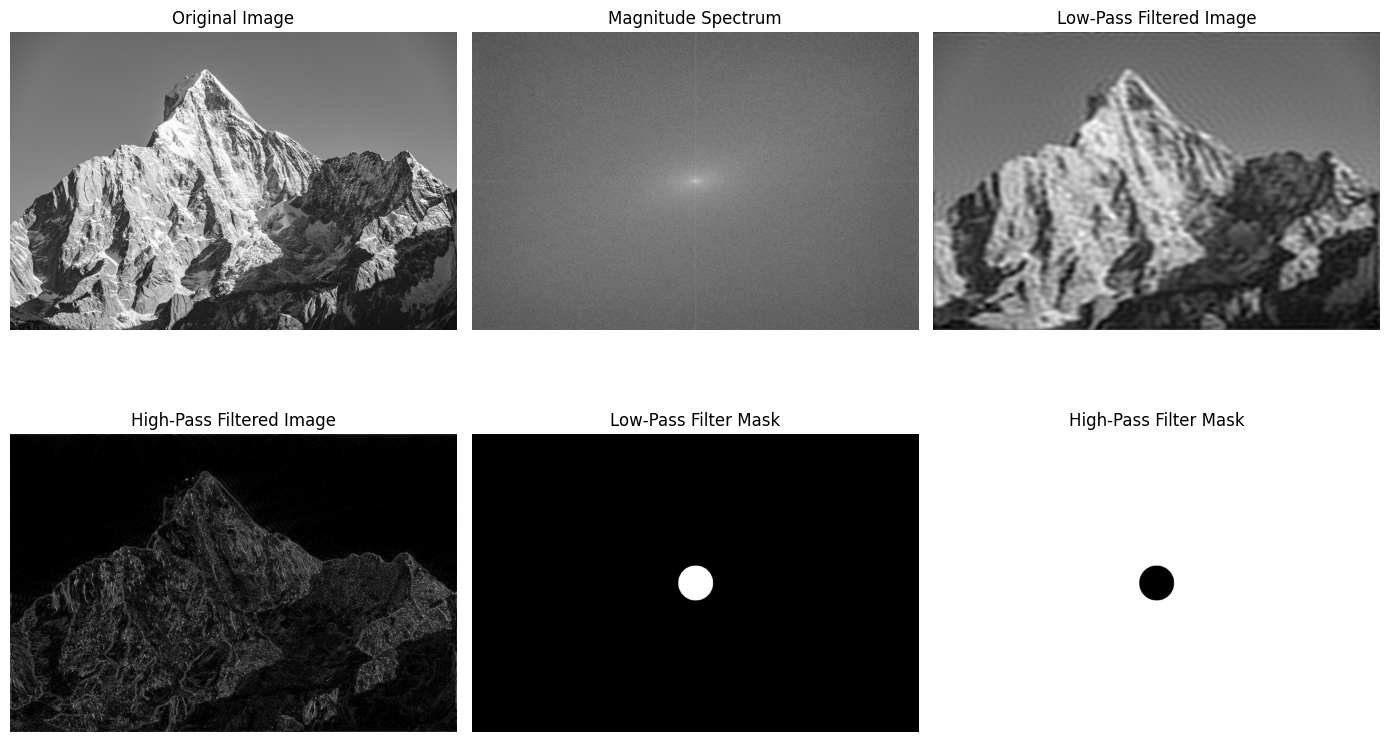


EXPERIMENT COMPLETED SUCCESSFULLY
Number of input images required: 1
Image size: (853, 1280)
Filter radius: 50
------------------------------------------
Low-Pass Filter:
Reduces high-frequency components.
Produces a smoother image.
Helps in noise reduction.
------------------------------------------
High-Pass Filter:
Removes low-frequency components.
Enhances edges and fine details.
Useful for feature extraction.


In [2]:
# ============================================================
# EXPERIMENT NO. 4
# Frequency Domain Image Filtering using Fourier Transform
# ============================================================

# Install/import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ------------------------------------------------------------
# STEP 1: AUTOMATICALLY UPLOAD ONE IMAGE
# ------------------------------------------------------------

print("Please upload ONE image.")

uploaded = files.upload()

# Get the uploaded file name automatically
file_name = list(uploaded.keys())[0]

print("Image uploaded successfully:", file_name)

# Read image as grayscale
img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

# Check image
if img is None:
    print("Error: Unable to read the uploaded image.")
else:

    print("Image size:", img.shape)

    # --------------------------------------------------------
    # STEP 2: COMPUTE DISCRETE FOURIER TRANSFORM (DFT)
    # --------------------------------------------------------

    dft = cv2.dft(
        np.float32(img),
        flags=cv2.DFT_COMPLEX_OUTPUT
    )

    # --------------------------------------------------------
    # STEP 3: SHIFT ZERO-FREQUENCY COMPONENT TO CENTER
    # --------------------------------------------------------

    dft_shift = np.fft.fftshift(dft)

    # --------------------------------------------------------
    # STEP 4: CALCULATE MAGNITUDE SPECTRUM
    # --------------------------------------------------------

    magnitude_spectrum = cv2.magnitude(
        dft_shift[:, :, 0],
        dft_shift[:, :, 1]
    )

    magnitude_spectrum = 20 * np.log(
        magnitude_spectrum + 1
    )

    # --------------------------------------------------------
    # STEP 5: CREATE LOW-PASS FILTER
    # --------------------------------------------------------

    rows, cols = img.shape

    crow = rows // 2
    ccol = cols // 2

    # Filter radius
    radius = 50

    # Create low-pass mask
    low_pass_mask = np.zeros(
        (rows, cols, 2),
        np.uint8
    )

    cv2.circle(
        low_pass_mask,
        (ccol, crow),
        radius,
        (1, 1),
        -1
    )

    # Apply low-pass filter
    low_pass_shift = dft_shift * low_pass_mask

    # Shift back
    low_pass_ishift = np.fft.ifftshift(
        low_pass_shift
    )

    # Inverse DFT
    low_pass_image = cv2.idft(
        low_pass_ishift
    )

    # Magnitude
    low_pass_image = cv2.magnitude(
        low_pass_image[:, :, 0],
        low_pass_image[:, :, 1]
    )

    # Normalize
    low_pass_image = cv2.normalize(
        low_pass_image,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    low_pass_image = np.uint8(
        low_pass_image
    )

    # --------------------------------------------------------
    # STEP 6: CREATE HIGH-PASS FILTER
    # --------------------------------------------------------

    # Create high-pass mask
    high_pass_mask = np.ones(
        (rows, cols, 2),
        np.uint8
    )

    # Remove low-frequency components
    cv2.circle(
        high_pass_mask,
        (ccol, crow),
        radius,
        (0, 0),
        -1
    )

    # Apply high-pass filter
    high_pass_shift = dft_shift * high_pass_mask

    # Shift back
    high_pass_ishift = np.fft.ifftshift(
        high_pass_shift
    )

    # Inverse DFT
    high_pass_image = cv2.idft(
        high_pass_ishift
    )

    # Magnitude
    high_pass_image = cv2.magnitude(
        high_pass_image[:, :, 0],
        high_pass_image[:, :, 1]
    )

    # Normalize
    high_pass_image = cv2.normalize(
        high_pass_image,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    high_pass_image = np.uint8(
        high_pass_image
    )

    # --------------------------------------------------------
    # STEP 7: DISPLAY ALL RESULTS
    # --------------------------------------------------------

    plt.figure(figsize=(14, 9))

    # Original Image
    plt.subplot(2, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    # Magnitude Spectrum
    plt.subplot(2, 3, 2)
    plt.imshow(
        magnitude_spectrum,
        cmap="gray"
    )
    plt.title("Magnitude Spectrum")
    plt.axis("off")

    # Low-Pass Image
    plt.subplot(2, 3, 3)
    plt.imshow(
        low_pass_image,
        cmap="gray"
    )
    plt.title("Low-Pass Filtered Image")
    plt.axis("off")

    # High-Pass Image
    plt.subplot(2, 3, 4)
    plt.imshow(
        high_pass_image,
        cmap="gray"
    )
    plt.title("High-Pass Filtered Image")
    plt.axis("off")

    # Low-Pass Mask
    plt.subplot(2, 3, 5)
    plt.imshow(
        low_pass_mask[:, :, 0],
        cmap="gray"
    )
    plt.title("Low-Pass Filter Mask")
    plt.axis("off")

    # High-Pass Mask
    plt.subplot(2, 3, 6)
    plt.imshow(
        high_pass_mask[:, :, 0],
        cmap="gray"
    )
    plt.title("High-Pass Filter Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # STEP 8: OBSERVATIONS
    # --------------------------------------------------------

    print("\n==========================================")
    print("EXPERIMENT COMPLETED SUCCESSFULLY")
    print("==========================================")
    print("Number of input images required: 1")
    print("Image size:", img.shape)
    print("Filter radius:", radius)
    print("------------------------------------------")
    print("Low-Pass Filter:")
    print("Reduces high-frequency components.")
    print("Produces a smoother image.")
    print("Helps in noise reduction.")
    print("------------------------------------------")
    print("High-Pass Filter:")
    print("Removes low-frequency components.")
    print("Enhances edges and fine details.")
    print("Useful for feature extraction.")
    print("==========================================")